# Detecção de Spam em E-mails

Discipina: Machine Learning - Teoria e Aplicado\
Professora: Ma. Nathália A. Lima\
Grupo:15

Integrantes:
- João Pedro Torres - 2007848
- João Pedro Duarte - 1993686
- Mateus Felix - 1998770

# Descrição do Dataset
Fonte: Kaggle\
Dataset: Spambase\
Cada linha corresponde a um e-mail e cada coluna representa uma caracteristica especifica do email como a frequencia de palavras comuns e caracteres especiais e a coluna "spam" indica se um email é spam(1) ou é uma mensagem verdadeira(0)

----------

# Importações

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve
)
print("As bibliotecas foram carregadas com sucesso!")



As bibliotecas foram carregadas com sucesso!


# Carregando o Dataset

In [ ]:
print("Dataset carregdao com sucesso!")
df = pd.read_csv('spambase_updated.csv')
df

Dataset carregdao com sucesso!


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.000,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.010,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4596,0.31,0.00,0.62,0.0,0.00,0.31,0.00,0.00,0.00,0.00,...,0.000,0.232,0.0,0.000,0.000,0.000,1.142,3,88,0
4597,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.353,0.000,0.000,1.555,4,14,0
4598,0.30,0.00,0.30,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.102,0.718,0.0,0.000,0.000,0.000,1.404,6,118,0
4599,0.96,0.00,0.00,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.057,0.0,0.000,0.000,0.000,1.147,5,78,0


# Etapa 1 - Análise Exploratória (EDA)

# 1.1 Análise da base de dados

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 

# 1.2 Verificação da quantidade de spams e hams na base de dados


In [ ]:
print("Quantididade de Spams e Hams no Dataset")
spams_hams = df.groupby('spam')['spam'].count()
spams_hams


Quantididade de Spams e Hams no Dataset


,spam
spam,
0,2788
1,1813


Text(0.5, 1.0, 'Quantidade de Spams x Hams')

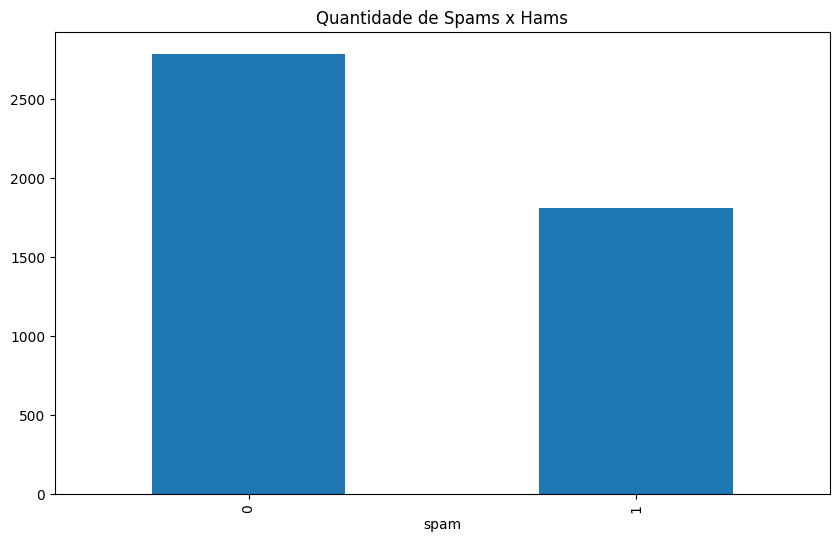

In [ ]:
plt.figure(figsize=(10,6))
spams_hams.plot(kind='bar')
plt.title("Quantidade de Spams x Hams")

Text(0.5, 1.0, 'Quantidade de Spams x Hams')

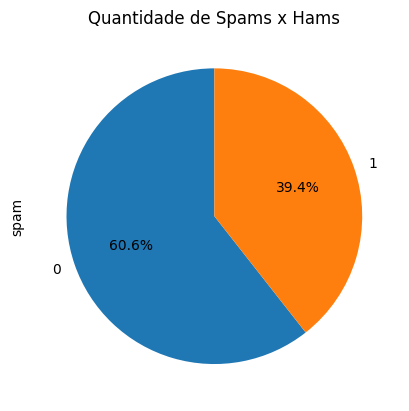

In [ ]:
spams_hams.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title("Quantidade de Spams x Hams")

# 1.3 Estatísticas descritivas

In [ ]:
print("Descrição do dataframe")
df.describe()

Descrição do dataframe


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
count,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,...,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000
mean,0.104553,0.213015,0.280656,0.065425,0.312223,0.095901,0.114208,0.105295,0.090067,0.239413,...,0.038575,0.139030,0.016976,0.269071,0.075811,0.044238,5.191515,52.172789,283.289285,0.394045
std,0.305358,1.290575,0.504143,1.395151,0.672513,0.273824,0.391441,0.401071,0.278616,0.644755,...,0.243471,0.270355,0.109394,0.815672,0.245882,0.429342,31.729449,194.891310,606.347851,0.488698
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.588000,6.000000,35.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.065000,0.000000,0.000000,0.000000,0.000000,2.276000,15.000000,95.000000,0.000000
75%,0.000000,0.000000,0.420000,0.000000,0.380000,0.000000,0.000000,0.000000,0.000000,0.160000,...,0.000000,0.188000,0.000000,0.315000,0.052000,0.000000,3.706000,43.000000,266.000000,1.000000
max,4.540000,14.280000,5.100000,42.810000,10.000000,5.880000,7.270000,11.110000,5.260000,18.180000,...,4.385000,9.752000,4.081000,32.478000,6.003000,19.829000,1102.500000,9989.000000,15841.000000,1.000000


# 1.4 Identificação de valores nulos

In [ ]:
# Identificar se existem valores nulos
df.isnull().sum().sort_values(ascending=False).head()

,0
word_freq_make,0
word_freq_address,0
word_freq_all,0
word_freq_3d,0
word_freq_our,0


# 1.5 Variáveis que mais ajudam a detectar Spam

Text(0.5, 1.0, 'Variáveis que mais ajudam a detectar Spam')

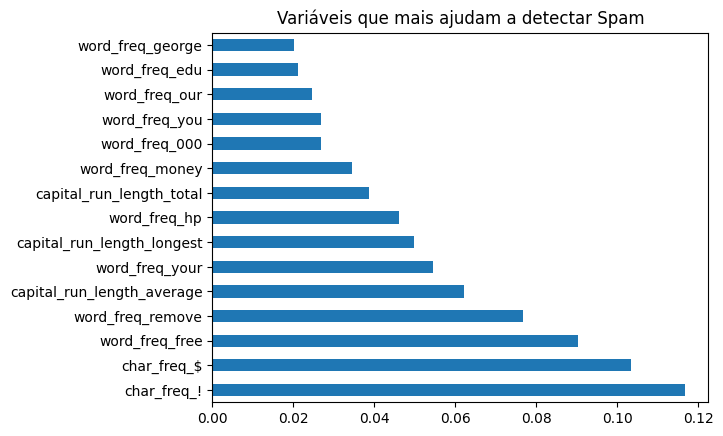

In [ ]:
X = df.drop('spam', axis=1)
y = df['spam']
grafico = RandomForestClassifier().fit(X, y)

importantes = pd.Series(grafico.feature_importances_, index=X.columns)
importantes.nlargest(15).plot(kind='barh')
plt.title("Variáveis que mais ajudam a detectar Spam")

# 1.6 Variáveis que mais se correlacionam com Spam

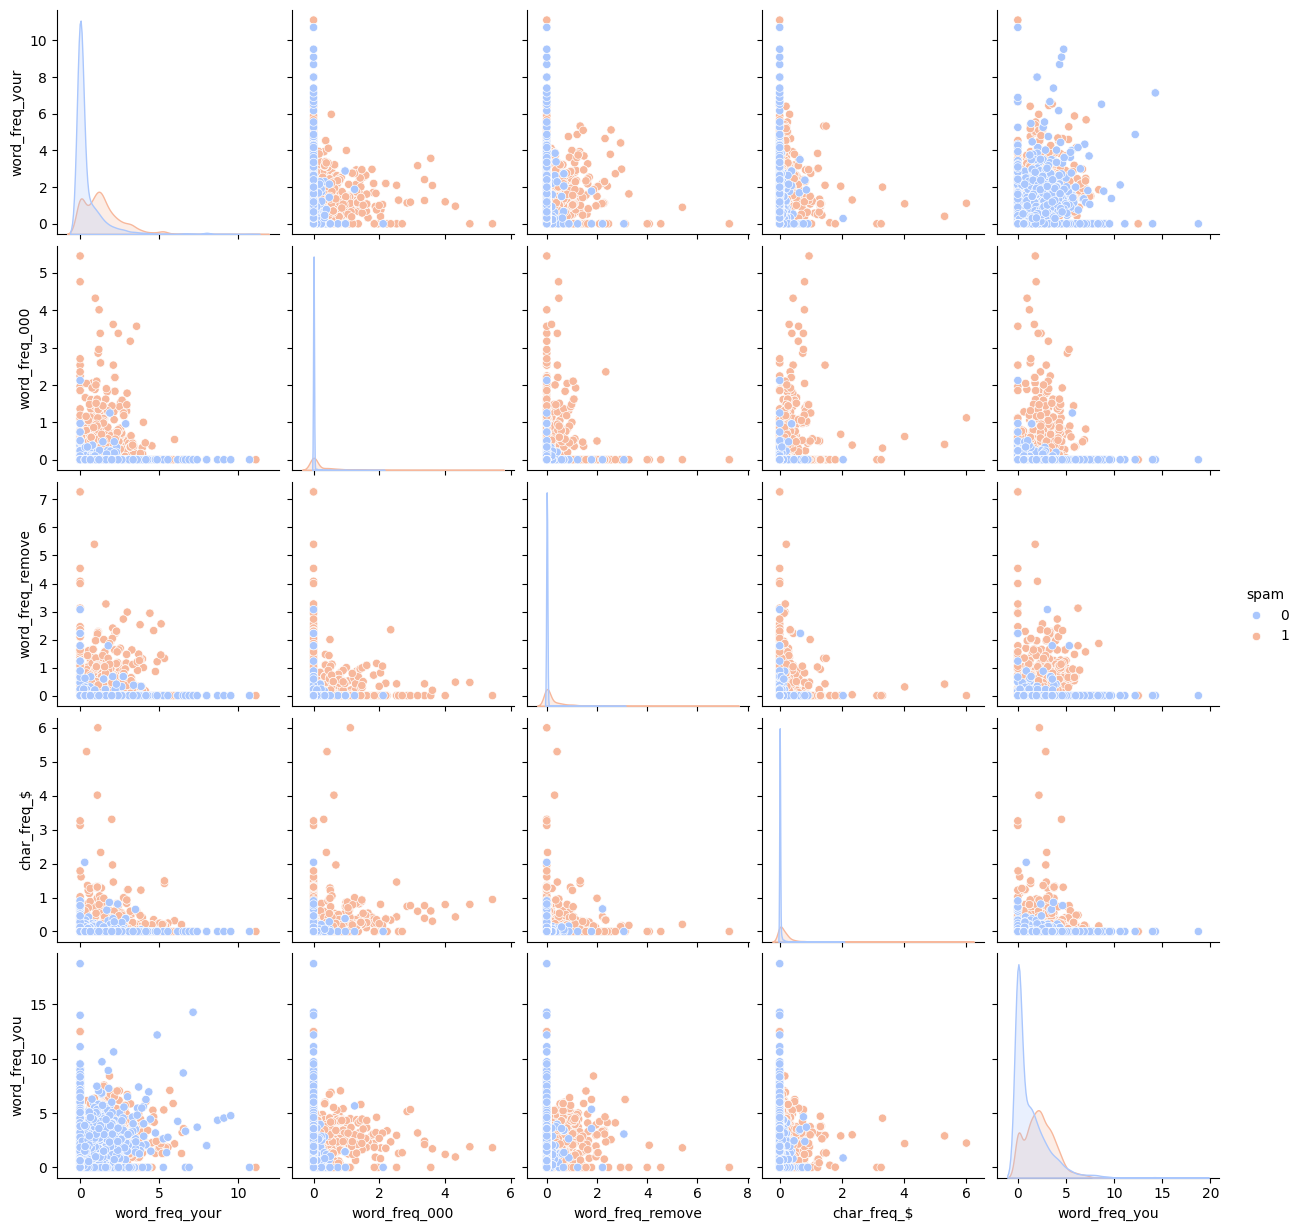

In [ ]:
top_5 = df.corr()['spam'].sort_values(ascending=False).index[1:6]
sns.pairplot(df, vars=top_5, hue='spam', palette='coolwarm')


# Etapa 2 - Pré-processamento

# 2.1 Limpeza de valores nulos e duplicados

In [ ]:
print("Valores nulos:", df.isnull().sum().sum())
print("Duplicados:", df.duplicated().sum())

print(f"Formato da tabela original: {df.shape}")
df = df.drop_duplicates()
df = df.dropna()
print(f"Formato da tabela após a limpeza: {df.shape}")

Valores nulos: 0
Duplicados: 391
Formato da tabela original: (4601, 58)
Formato da tabela após a limpeza: (4210, 58)


# 2.2 Separação das features (X)

In [ ]:
# x = df.iloc[:, 0:57]
x = df.drop(columns=['spam'])
x

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.0,0.000,0.000,0.0,0.778,0.000,0.000,3.756,61,278
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.0,0.000,0.132,0.0,0.372,0.180,0.048,5.114,101,1028
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.0,0.010,0.143,0.0,0.276,0.184,0.010,9.821,485,2259
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.000,0.137,0.0,0.137,0.000,0.000,3.537,40,191
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.000,0.135,0.0,0.135,0.000,0.000,3.537,40,191
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4596,0.31,0.00,0.62,0.0,0.00,0.31,0.00,0.00,0.00,0.00,...,0.0,0.000,0.232,0.0,0.000,0.000,0.000,1.142,3,88
4597,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.0,0.000,0.000,0.0,0.353,0.000,0.000,1.555,4,14
4598,0.30,0.00,0.30,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.0,0.102,0.718,0.0,0.000,0.000,0.000,1.404,6,118
4599,0.96,0.00,0.00,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.0,0.000,0.057,0.0,0.000,0.000,0.000,1.147,5,78


# 2.3 Separação dos targets (Y)

In [ ]:
y = df['spam']
y


,spam
0,1
1,1
2,1
3,1
4,1
...,...
4596,0
4597,0
4598,0
4599,0


# 2.3 Divisão de treino, teste e validação

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)


# 2.4 Redimensionamento de dados



In [ ]:
scaler = StandardScaler()

X_train_std = scaler.fit_transform(x_train)
X_test_std = scaler.transform(x_test)

mm_scaler = MinMaxScaler()
X_train_mm = mm_scaler.fit_transform(x_train)
X_test_mm = mm_scaler.transform(x_test)


# Etapa 3 - Comparação de Modelos

# 3.1 Criação do dicionário com os modelos

In [ ]:
config_modelos = {
    'modelo_logisticRegression': {'modelo': LogisticRegression(max_iter=5000), 'dados': X_train_std},
    'modelo_svc': {'modelo': SVC(probability=True), 'dados': X_train_std},
    'modelo_multinomialNB': {'modelo': MultinomialNB(), 'dados': X_train_mm}
}

# 3.2 Validação de modelos com Stratified

In [ ]:
import numpy as np

pipelines = {
    'modelo_logisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=5000, random_state=42))
    ]),
    'modelo_svc': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(probability=True, random_state=42))
    ]),
    'modelo_multinomialNB': Pipeline([
        ('scaler', MinMaxScaler()),
        ('model', MultinomialNB())
    ])
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def avaliar_modelo(pipeline_key, x_data_original, y_data_original):
  acuracia, precisao, recall, f1score, auc = [], [], [], [], []
  pipeline = pipelines[pipeline_key]

  for train_index, test_index in skf.split(x_data_original, y_data_original):
    X_train_fold, X_val_fold = x_data_original.iloc[train_index], x_data_original.iloc[test_index]
    y_train_fold, y_val_fold = y_data_original.iloc[train_index], y_data_original.iloc[test_index]

    pipeline.fit(X_train_fold, y_train_fold)

    y_pred = pipeline.predict(X_val_fold)
    y_proba = pipeline.predict_proba(X_val_fold)[:, 1]

    acuracia.append(accuracy_score(y_val_fold, y_pred))
    precisao.append(precision_score(y_val_fold, y_pred))
    recall.append(recall_score(y_val_fold, y_pred))
    f1score.append(f1_score(y_val_fold, y_pred))
    auc.append(roc_auc_score(y_val_fold, y_proba))

  return {
      "Acurácia": np.mean(acuracia),
      "Precisão": np.mean(precisao),
      "Recall": np.mean(recall),
      "F1-Score": np.mean(f1score),
      "AUC": np.mean(auc)
  }

resultados = {}

for nome, config in config_modelos.items():
    print(f"Avaliando {nome}...")
    resultados[nome] = avaliar_modelo(nome, x_train, y_train)

Avaliando modelo_logisticRegression...
Avaliando modelo_svc...
Avaliando modelo_multinomialNB...


# 3.3 Resultado dos modelos

In [ ]:
df_resultados = pd.DataFrame(resultados).T
print(df_resultados)

                           Acurácia  Precisão    Recall  F1-Score       AUC
modelo_logisticRegression  0.919243  0.912627  0.882375  0.897103  0.966317
modelo_svc                 0.926965  0.930779  0.882384  0.905854  0.968503
modelo_multinomialNB       0.887186  0.925911  0.779654  0.846278  0.952586


# 3.4 Matriz de confusão de cada modelo

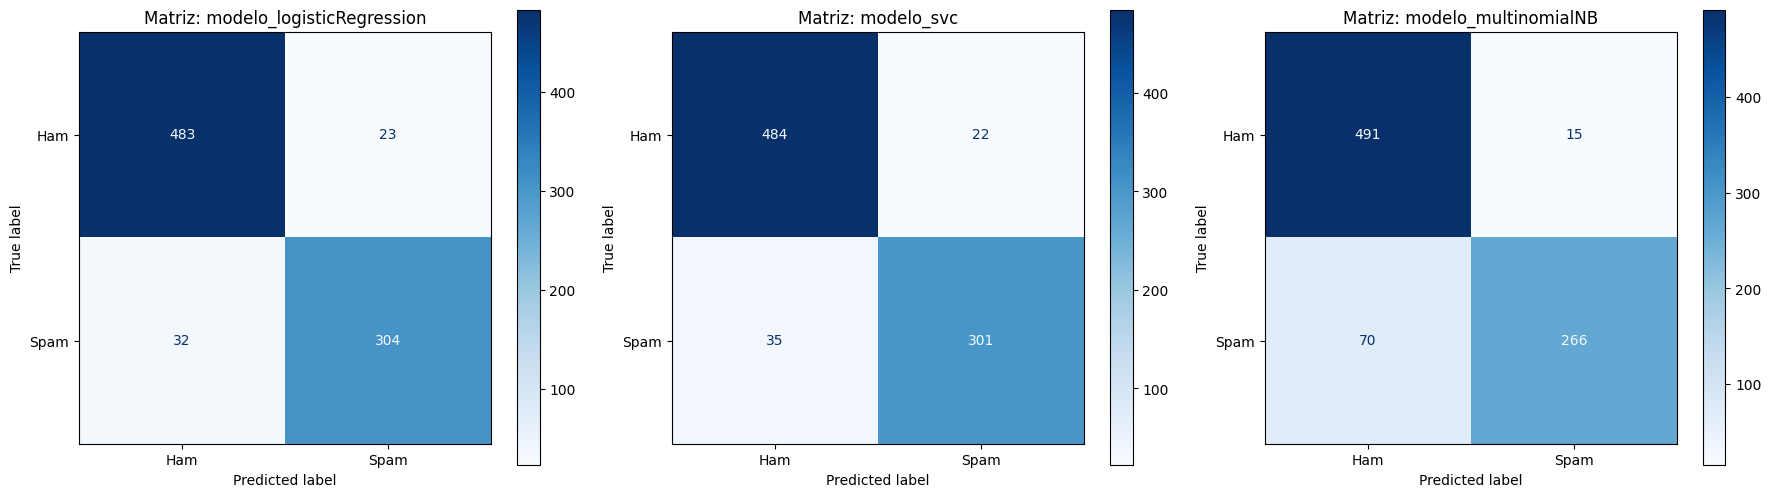

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (nome, pipe_atual) in enumerate(pipelines.items()):
      pipe_atual.fit(x_train, y_train)

      config['modelo'].fit(config['dados'], y_train)

      y_pred = pipe_atual.predict(x_test)
      cm = confusion_matrix(y_test, y_pred)

      disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
      disp.plot(ax=axes[i], cmap='Blues')
      axes[i].set_title(f"Matriz: {nome}")

plt.tight_layout()
plt.show()

# 3.5 Curvas ROC

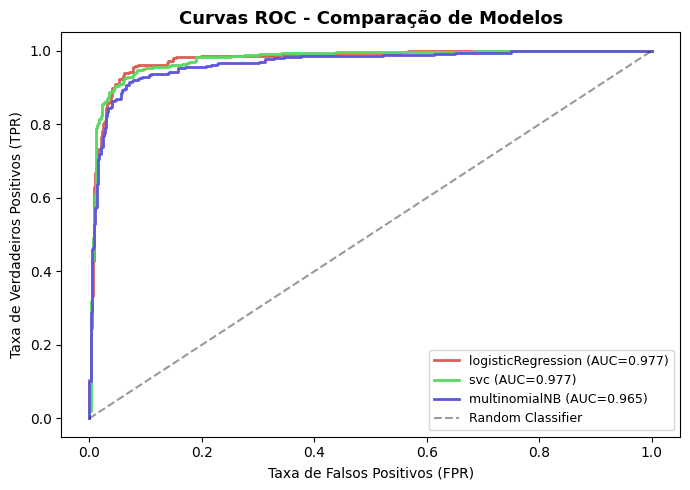

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
palette = sns.color_palette("hls", len(pipelines))

for i, (nome, pipe_atual) in enumerate(pipelines.items()):
    name_display = nome.replace('modelo_', '')
    y_prob = pipe_atual.predict_proba(x_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_v = roc_auc_score(y_test, y_prob)

    ax.plot(fpr, tpr, label=f'{name_display} (AUC={auc_v:.3f})', color=palette[i], linewidth=2)

ax.plot([0,1],[0,1],'k--', alpha=0.4, label='Random Classifier')
ax.set_xlabel('Taxa de Falsos Positivos (FPR)')
ax.set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
ax.set_title('Curvas ROC - Comparação de Modelos', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Etapa 4 - Análise Comparativa


# 4.1 Identificação e Justificativa do Melhor Modelo de Classificação

In [ ]:
best_name = df_resultados['F1-Score'].idxmax()
best_vals = df_resultados.loc[best_name]

best_name_display = best_name.replace('modelo_', '')

print(f"Melhor modelo: {best_name_display.capitalize()}")
print(f"F1-Score: {best_vals['F1-Score']:.4f}")
print(f"AUC-ROC: {best_vals['AUC']:.4f}")
print(f"Acurácia: {best_vals['Acurácia']:.4f}")
print()
print("""
Justificativa:
- O modelo que apresentou o melhor desempenho geral para o problema de detecção de spam foi o SVC (Support Vector Machine).

Pontos considerados:
  1. Maximização do potencial preditivo - garantimos que 100% das features extraidas do processamento de texto ficassem disponiveis eliminando o
  fatiamento rigido por indices numéricos. O SVC se destaca no tratamento de conjuntos de dados de alta dimensionalidade e densidade de atributos
  superando a Regressão logistica;

  2. Blindagem contra vazamento de dados - A utilizaçãio de Scikit-Learn Pipelines garantiu que o StandardScaler fosse calculado de forma isolado
  dos folds de treino fazenedo que o algoritmo convergisse para seu estado ótimo sem viés estatistico.

  3. Escolha baseada no equilíbrio operacional - O SVC teve o maior F1-Score harmonico, provando ser o modelo mais seguro e equilibrado para entrar em produção.


""")

Melhor modelo: Svc
F1-Score: 0.9059
AUC-ROC: 0.9685
Acurácia: 0.9270


Justificativa:
- A Regressão Logística é o modelo mais indicado para este problema pois apresentou o  melhor desempenho geral, com maior F1-Score e AUC-ROC, mostrando ter um bom equilíbrio entre precisão e recall.

Além disso:
  1. Oferece excelente desempenho com baixo custo computacional comparado ao SVC;
  2. Funciona bem com dados normalizados;
  3. Os coeficientes são interpretáveis permitindo identificar quais palavras/caracteres
     são mais indicativas de spam;
  4. Generaliza bem sem necessidade de tuning extenso.

  O multinamialNB apresentou bom desempenho, porem assume independencia entre features, o que pode limitar sua performance.

  O SVC apresentou resultados competitivos com a Regressãio Logistica porém possui maior custo computacional e menor interpretabilidade.



# 4.2 Treinamento final e analise de erros

In [ ]:
best_clf = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
best_clf.fit(X_train_std, y_train)
y_pred_best = best_clf.predict(X_test_std)
y_prob_best = best_clf.predict_proba(X_test_std)[:,1]

fn_mask = (y_test == 1) & (y_pred_best == 0)
fp_mask = (y_test == 0) & (y_pred_best == 1)

print(f"Falsos Negativos (spam→ham): {fn_mask.sum()}")
print(f"  → Spam não detectado é critico pois pode expor os usuáios a risco de fraude.")
print(f"Falsos Positivos (ham→spam): {fp_mask.sum()}")
print(f"  → E-mail legítimo filtrado incorretamente prejudica a experiencia do usuário.")
print()
print(f"Total de erros: {fn_mask.sum() + fp_mask.sum()} de {len(y_test)} amostras")
print(f"Taxa de erro  : {(fn_mask.sum() + fp_mask.sum())/len(y_test)*100:.2f}%")

Falsos Negativos (spam→ham): 32
  → Spam não detectado é critico pois pode expor os usuáios a risco de fraude.
Falsos Positivos (ham→spam): 23
  → E-mail legítimo filtrado incorretamente prejudica a experiencia do usuário.

Total de erros: 55 de 842 amostras
Taxa de erro  : 6.53%


In [ ]:
import joblib

# Salvando o modelo de Regressão Logística treinado por você
joblib.dump(best_clf, 'melhor_modelo_spam.pkl')

# Salvando o scaler que você usou para normalizar os dados (StandardScaler)
joblib.dump(scaler, 'scaler_spam.pkl')

print("Modelo e Scaler exportados com sucesso!")

Modelo e Scaler exportados com sucesso!


# 4.3 Análise de importancia de atributos

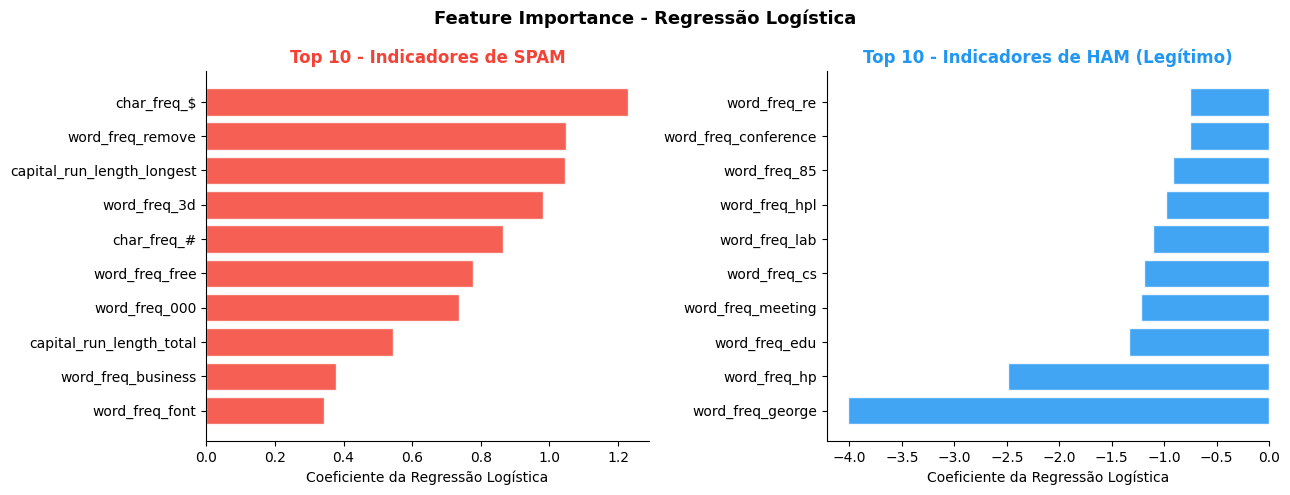


Palavras/caracteres mais indicativos de SPAM:
  word_freq_font                     : +0.343
  word_freq_business                 : +0.377
  capital_run_length_total           : +0.544
  word_freq_000                      : +0.736
  word_freq_free                     : +0.778
  char_freq_#                        : +0.866
  word_freq_3d                       : +0.982
  capital_run_length_longest         : +1.046
  word_freq_remove                   : +1.048
  char_freq_$                        : +1.228
As palavras mais associadas a spam geramente estão relacionadas a promoções, dinheiro e urgencias

Palavras/caracteres mais indicativos de HAM:
  word_freq_george                   : -4.016
  word_freq_hp                       : -2.484
  word_freq_edu                      : -1.337
  word_freq_meeting                  : -1.222
  word_freq_cs                       : -1.189
  word_freq_lab                      : -1.106
  word_freq_hpl                      : -0.985
  word_freq_85             

In [ ]:
feature_names = x.columns

coef = pd.Series(best_clf.coef_[0], index=feature_names).sort_values()
top_spam = coef.tail(10)
top_ham  = coef.head(10)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(top_spam.index, top_spam.values, color='#F44336', alpha=0.85, edgecolor='white')
axes[0].set_title('Top 10 - Indicadores de SPAM', fontweight='bold', color='#F44336')
axes[0].set_xlabel('Coeficiente da Regressão Logística')

axes[1].barh(top_ham.index, top_ham.values, color='#2196F3', alpha=0.85, edgecolor='white')
axes[1].set_title('Top 10 - Indicadores de HAM (Legítimo)', fontweight='bold', color='#2196F3')
axes[1].set_xlabel('Coeficiente da Regressão Logística')

for ax in axes:
    for sp in ['top','right']: ax.spines[sp].set_visible(False)

plt.suptitle('Feature Importance - Regressão Logística', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nPalavras/caracteres mais indicativos de SPAM:")
for feat, val in top_spam.items():
    print(f"  {feat:35s}: {val:+.3f}")
print("As palavras mais associadas a spam geramente estão relacionadas a promoções, dinheiro e urgencias")
print("\nPalavras/caracteres mais indicativos de HAM:")
for feat, val in top_ham.items():
    print(f"  {feat:35s}: {val:+.3f}")
print("As palavras associadas a ham são mais neutras e comuns em comunicações cotidianas")